In [7]:
# --- 1. Imports & Setup ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache

# Custom Style
import viz_style
viz_style.set_architectural_style()

print("Libraries imported.")

Architectural plot style applied (Dark Mode).
Libraries imported.


In [8]:
# --- 2. Load Session Data ---
output_dir = "../Dataset/RAW"
manifest_path = os.path.join(output_dir, "manifest.json")
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)

session_id = 715093703 
print(f"Loading Session {session_id}...")
session = cache.get_session_data(session_id)

# List Probes
print("\nAvailable Probes:")
print(session.probes.head())

Loading Session 715093703...


/opt/anaconda3/envs/TDA/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)



Available Probes:
          description                 location  sampling_rate  \
id                                                              
810755797      probeA  See electrode locations   29999.954846   
810755799      probeB  See electrode locations   29999.906318   
810755801      probeC  See electrode locations   29999.985470   
810755803      probeD  See electrode locations   29999.908100   
810755805      probeE  See electrode locations   29999.985679   

           lfp_sampling_rate  has_lfp_data  
id                                          
810755797        1249.998119          True  
810755799        1249.996097          True  
810755801        1249.999395          True  
810755803        1249.996171          True  
810755805        1249.999403          True  
          description                 location  sampling_rate  \
id                                                              
810755797      probeA  See electrode locations   29999.954846   
810755799      

In [9]:
# --- 3. Select Probe & Extract Data ---

# Find a probe that contains CA1 units
target_structure = "CA1"
probe_id = None

for pid in session.probes.index:
    # Check if this probe has units in CA1
    probe_units = session.units[session.units.probe_id == pid]
    structures = probe_units['ecephys_structure_acronym'].unique()
    if target_structure in structures:
        probe_id = pid
        print(f"Found probe {probe_id} containing {target_structure}.")
        break

if probe_id is None:
    probe_id = session.probes.index[0]
    print(f"Target structure {target_structure} not found. Using first probe {probe_id}.")

# Get Units and Channels for this probe
units = session.units[session.units.probe_id == probe_id]
channels = session.channels[session.channels.probe_id == probe_id]

print(f"Probe {probe_id}: {len(units)} units, {len(channels)} channels.")
print("Unit Columns:", units.columns)

/opt/anaconda3/envs/TDA/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)
/opt/anaconda3/envs/TDA/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)
/opt/anaconda3/envs/TDA/lib/python3.11/site-packages

Found probe 810755797 containing CA1.
Probe 810755797: 78 units, 374 channels.
Unit Columns: Index(['waveform_PT_ratio', 'waveform_amplitude', 'amplitude_cutoff',
       'cluster_id', 'cumulative_drift', 'd_prime', 'firing_rate',
       'isi_violations', 'isolation_distance', 'L_ratio', 'local_index',
       'max_drift', 'nn_hit_rate', 'nn_miss_rate', 'peak_channel_id',
       'presence_ratio', 'waveform_recovery_slope',
       'waveform_repolarization_slope', 'silhouette_score', 'snr',
       'waveform_spread', 'waveform_velocity_above', 'waveform_velocity_below',
       'waveform_duration', 'filtering', 'probe_channel_number',
       'probe_horizontal_position', 'probe_id', 'probe_vertical_position',
       'structure_acronym', 'ecephys_structure_id',
       'ecephys_structure_acronym', 'anterior_posterior_ccf_coordinate',
       'dorsal_ventral_ccf_coordinate', 'left_right_ccf_coordinate',
       'probe_description', 'location', 'probe_sampling_rate',
       'probe_lfp_sampling_rate

Calculating spike correlations...
Drawing 152 connections (Threshold: 0.159)...
Drawing 152 connections (Threshold: 0.159)...


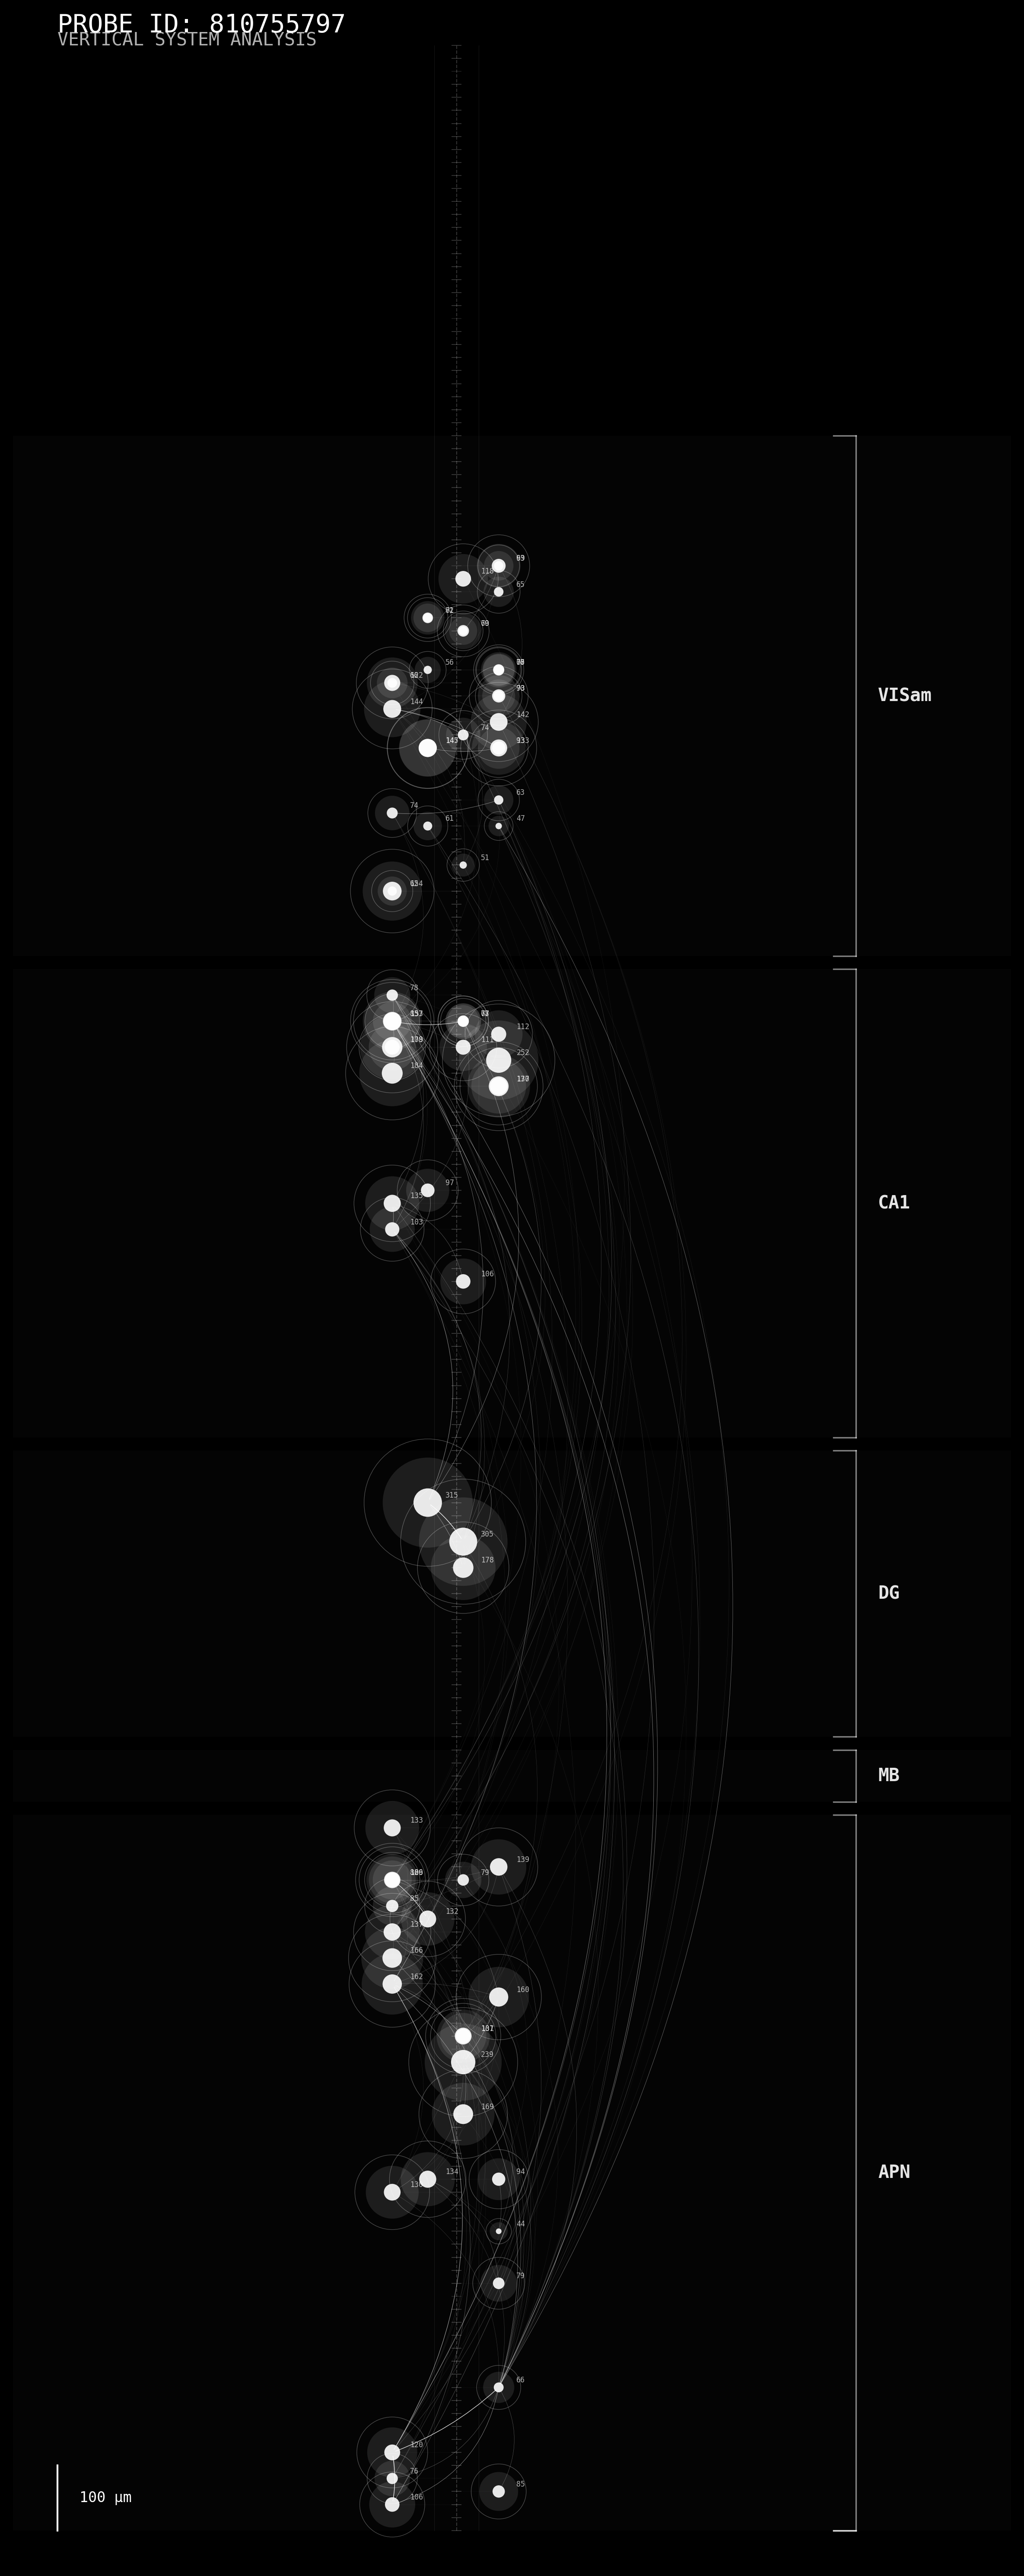

In [24]:
# --- 4. Architectural / Sci-Fi Visualization ---

def plot_architectural_probe(units, channels, probe_id, session):
    # 1. Calculate Correlations
    corr_df = calculate_correlations(session, units.index.values)
    
    # 2. Setup Figure (High Res, Vertical)
    fig, ax = plt.subplots(figsize=(8, 20), dpi=300)
    fig.patch.set_facecolor("#000000") # Almost black
    ax.set_facecolor("#000000")
    
    # Constants
    X_CENTER = 0
    PROBE_WIDTH = 40
    
    # --- A. Vertical Structure (The "Probe") ---
    # Draw a complex vertical shaft
    depth_min = channels['probe_vertical_position'].min()
    depth_max = channels['probe_vertical_position'].max()
    
    # Main Axis
    ax.plot([X_CENTER, X_CENTER], [depth_min, depth_max], color='white', linewidth=0.5, alpha=0.2, linestyle='--')
    ax.plot([X_CENTER-10, X_CENTER-10], [depth_min, depth_max], color='white', linewidth=0.2, alpha=0.1)
    ax.plot([X_CENTER+10, X_CENTER+10], [depth_min, depth_max], color='white', linewidth=0.2, alpha=0.1)
    
    # Channel ticks
    for y in channels['probe_vertical_position']:
        ax.plot([X_CENTER-2, X_CENTER+2], [y, y], color='white', linewidth=0.5, alpha=0.1)

    # --- B. Brain Regions (Architectural Zones) ---
    sorted_channels = channels.sort_values('probe_vertical_position')
    current_struct = None
    start_pos = sorted_channels.iloc[0]['probe_vertical_position']
    
    # Identify regions
    regions = []
    for i in range(1, len(sorted_channels)):
        row = sorted_channels.iloc[i]
        struct = row['ecephys_structure_acronym']
        if struct != current_struct:
            regions.append((current_struct, start_pos, sorted_channels.iloc[i-1]['probe_vertical_position']))
            current_struct = struct
            start_pos = row['probe_vertical_position']
    regions.append((current_struct, start_pos, sorted_channels.iloc[-1]['probe_vertical_position']))
    
    # Draw Regions
    for struct, start, end in regions:
        if str(struct) == 'nan': continue
        mid = (start + end) / 2
        height = end - start
        
        # Zone Bracket
        bracket_x = X_CENTER + 180
        ax.plot([bracket_x, bracket_x], [start, end], color='white', linewidth=0.8, alpha=0.5) # Vertical line
        ax.plot([bracket_x, bracket_x-10], [start, start], color='white', linewidth=0.8, alpha=0.5) # Top tick
        ax.plot([bracket_x, bracket_x-10], [end, end], color='white', linewidth=0.8, alpha=0.5) # Bottom tick
        
        # Label
        ax.text(bracket_x + 10, mid, struct, color='white', fontsize=10, 
                verticalalignment='center', fontfamily='monospace', fontweight='bold', alpha=0.9)
        
        # Faint background fill
        rect = patches.Rectangle((X_CENTER - 250, start), 500, height, 
                                 facecolor='white', alpha=0.02, edgecolor='none')
        ax.add_patch(rect)

    # --- C. Units (The "Nodes") ---
    # Positions
    if 'probe_horizontal_position' in units.columns:
        x_vals = units['probe_horizontal_position'].values - 40 # Center around 0
    else:
        x_vals = np.random.normal(0, 20, size=len(units))
    y_vals = units['probe_vertical_position'].values
    
    # Sizes (Amplitude)
    possible_amp_cols = ['amplitude', 'spike_amplitude', 'waveform_amplitude']
    amp_col = next((col for col in possible_amp_cols if col in units.columns), None)
    amplitudes = units[amp_col].values if amp_col else np.ones(len(units))*100
    
    # Normalize sizes for drawing
    # Base size + dynamic range
    sizes_norm = (amplitudes - amplitudes.min()) / (amplitudes.max() - amplitudes.min() + 1e-9)
    
    # Increased base size for better visibility
    s_base = 50 + 1200 * sizes_norm 
    
    # Draw Connections (Correlations)
    corr_values = corr_df.values
    # Lower threshold to show more connections (e.g., Top 5% instead of 1%)
    threshold = np.percentile(np.abs(corr_values), 95.0) 
    rows, cols = np.where(np.abs(corr_values) > threshold)
    
    unit_pos = {uid: (x, y) for uid, x, y in zip(units.index, x_vals, y_vals)}
    
    print(f"Drawing {len(rows)//2} connections (Threshold: {threshold:.3f})...")
    
    for r, c in zip(rows, cols):
        if r >= c: continue
        u1, u2 = corr_df.index[r], corr_df.index[c]
        if u1 not in unit_pos or u2 not in unit_pos: continue
        
        p1, p2 = unit_pos[u1], unit_pos[u2]
        
        # Style: Thin, white, curved lines
        # Opacity based on correlation strength
        strength = (abs(corr_values[r,c]) - threshold) / (1 - threshold)
        alpha = 0.1 + 2 * strength # Lower base alpha for more lines
        lw = 0.1 + 0.6 * strength
        
        # Bezier Curve
        rad = 0.3 if abs(p1[1] - p2[1]) > 100 else 0.1
        arrow = patches.FancyArrowPatch(p1, p2, 
                                        connectionstyle=f"arc3,rad={rad}", 
                                        color='white',
                                        linewidth=lw,
                                        alpha=alpha,
                                        arrowstyle='-')
        ax.add_patch(arrow)

    # Draw Units (Complex Glyphs)
    # 1. Outer Ring (Thin)
    ax.scatter(x_vals, y_vals, s=s_base*4, facecolors='none', edgecolors='white', linewidths=0.3, alpha=0.3)
    
    # 2. Inner Glow (Faint Fill)
    ax.scatter(x_vals, y_vals, s=s_base*2, c='white', alpha=0.1, edgecolors='none')
    
    # 3. Core (Solid)
    ax.scatter(x_vals, y_vals, s=s_base*0.2, c='white', alpha=0.9, edgecolors='none')
    
    # 4. Leader Lines to Shaft
    # Connect each unit to the center shaft with a very thin horizontal line
    for x, y in zip(x_vals, y_vals):
        ax.plot([x, X_CENTER], [y, y], color='white', linewidth=0.1, alpha=0.1)
        
    # 5. Amplitude Labels (Numbers)
    # Add text label near each unit showing its amplitude
    for x, y, amp in zip(x_vals, y_vals, amplitudes):
        # Only label significant units to avoid clutter? Or all?
        # Let's label all but very small/faint text
        # Offset text slightly
        ax.text(x + 8, y + 8, f"{int(amp)}", color='white', fontsize=4, 
                fontfamily='monospace', alpha=0.7)

    # --- D. Formatting ---
    ax.set_xlim(-200, 250)
    ax.set_ylim(depth_min - 50, depth_max + 50)
    
    # Remove axes
    ax.axis('off')
    
    # Title / Metadata
    ax.text(-180, depth_max + 20, f"PROBE ID: {probe_id}", color='white', fontsize=14, fontfamily='monospace')
    ax.text(-180, depth_max, "VERTICAL SYSTEM ANALYSIS", color='white', fontsize=10, fontfamily='monospace', alpha=0.7)
    
    # Scale Bar
    ax.plot([-180, -180], [depth_min, depth_min + 100], color='white', linewidth=1)
    ax.text(-170, depth_min + 50, "100 μm", color='white', fontsize=8, fontfamily='monospace', verticalalignment='center')

    plt.tight_layout()
    plt.show()

plot_architectural_probe(units, channels, probe_id, session)